# SWOT LakeSP data search and download over Vietnam

This notebook demonstrates how to search for and download **SWOT LakeSP** products from NASA Earthdata using a predefined geographic rectangle.

The workflow is organized into three main steps:

1. Define an approximate geographic bounding box covering Vietnam.
2. Search NASA Earthdata for SWOT LakeSP granules intersecting that region.
3. Download the selected granules using a safe download routine with retries, duplicate protection, temporary folders, and logging.

> **Training note:** The rectangle used here is intentionally approximate. It covers Vietnam and also includes small portions of neighboring countries and adjacent ocean areas. This is normal when using a simple rectangular bounding box.


## 1. Define an approximate bounding box for Vietnam

A **bounding box** is the simplest way to define a rectangular geographic search area.

For this exercise, we use approximately:

- **West:** 102°E
- **East:** 110°E
- **South:** 8°N
- **North:** 24°N

These values are deliberately rounded so that the entire country is included.

The `shapely.geometry.box()` function creates a rectangle using the order:

```text
box(min_longitude, min_latitude, max_longitude, max_latitude)
```

The resulting `aoi.bounds` can be passed directly to `earthaccess.search_data()`.


Vietnam approximate bounding box: (102.0, 8.0, 110.0, 24.0)


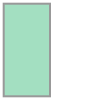

In [4]:
from shapely.geometry import box

# ------------------------------------------------------------
# APPROXIMATE GEOGRAPHIC EXTENT OF VIETNAM
# ------------------------------------------------------------
#
# Coordinates are expressed in decimal degrees:
#
# Longitude:
#   negative = west of Greenwich
#   positive = east of Greenwich
#
# Latitude:
#   negative = south of the Equator
#   positive = north of the Equator
#
# The values below are intentionally rounded to create a simple
# rectangle that covers the entire country of Vietnam.
WEST = 102.0
SOUTH = 8.0
EAST = 110.0
NORTH = 24.0

# Create the rectangular Area Of Interest (AOI).
#
# box() expects:
# box(min_longitude, min_latitude, max_longitude, max_latitude)
aoi = box(WEST, SOUTH, EAST, NORTH)

# Display the rectangle bounds.
# The result follows the order:
# (minimum longitude, minimum latitude, maximum longitude, maximum latitude)
print("Vietnam approximate bounding box:", aoi.bounds)

# Optional: display the polygon representation.
aoi


## 2. Search for SWOT LakeSP granules

This example searches the **SWOT Level-2 High-Rate LakeSP** collection:

```text
SWOT_L2_HR_LAKESP_D
```

The search is restricted by:

- the geographic rectangle defined above;
- a temporal interval;
- granule names containing `prior`.

For LakeSP products, the `*prior*` filter selects the **prior lake** files.

The complete Earthaccess result objects are stored in `results`. These objects are required later by the download routine.


In [5]:
import earthaccess

# Authenticate with NASA Earthdata.
#
# persist=True stores the authentication information locally so that
# the user usually does not need to log in again in every notebook cell.
earthaccess.login(persist=True)

# ------------------------------------------------------------
# SEARCH PARAMETERS
# ------------------------------------------------------------

# NASA Earthdata short name for the SWOT LakeSP product.
SHORT_NAME = "SWOT_L2_HR_LAKESP_D"

# Time interval used in this training example.
START_DATE = "2025-01-01"
END_DATE = "2026-08-17"

# '*prior*' restricts the search to LakeSP prior-lake granules.
GRANULE_PATTERN = "*prior*"

# ------------------------------------------------------------
# SEARCH NASA EARTHDATA
# ------------------------------------------------------------

results = earthaccess.search_data(
    short_name=SHORT_NAME,
    temporal=(START_DATE, END_DATE),
    granule_name=GRANULE_PATTERN,
    bounding_box=aoi.bounds
)

# `results` contains the complete Earthaccess objects.
# For display purposes, we extract only the native granule names.
items = [
    item["meta"]["native-id"]
    for item in results
]

print("============================================================")
print("SWOT LakeSP granules found")
print("============================================================")
print(f"Total granules: {len(items)}")
print(f"Time period: {START_DATE} to {END_DATE}")
print(f"Bounding box: {aoi.bounds}")
print()

# Display the granule names.
for item in items:
    print(item)


SWOT LakeSP granules found
Total granules: 1014
Time period: 2025-01-01 to 2026-08-17
Bounding box: (102.0, 8.0, 110.0, 24.0)

SWOT_L2_HR_LakeSP_Prior_026_243_AS_20250101T122005_20250101T123304_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_256_AS_20250101T231058_20250101T231853_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_271_AS_20250102T121946_20250102T123325_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_284_AS_20250102T231159_20250102T231935_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_299_AS_20250103T121805_20250103T123406_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_312_AS_20250103T231240_20250103T232024_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_327_AS_20250104T121926_20250104T123357_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_340_AS_20250104T231301_20250104T232140_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_355_AS_20250105T122107_20250105T123328_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_368_AS_20250105T231332_20250105T232431_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_383_AS_20250106T122400_20250106T123319_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_396_AS_20250106T2314

## 3. Download the selected granules

The download section below is more robust than a minimal `earthaccess.download()` call.

It is designed for classroom use and illustrates several good practices:

- use a platform-independent path with `Path.home()`;
- keep the full Earthaccess result objects for downloading;
- optionally limit the number of downloads during testing;
- remove duplicate search results;
- download each granule into an isolated temporary folder;
- retry failed downloads;
- prevent existing files from being overwritten;
- preserve files with the same name but different sizes;
- record detailed messages in a log file;
- display one progress bar for the entire download process.

The output directory works on Windows, Linux, and macOS.


In [ ]:
import os
import sys
import time
import shutil
import inspect
import contextlib

from pathlib import Path
from datetime import datetime
from contextlib import contextmanager, ExitStack
from unittest.mock import patch

import earthaccess

from IPython.display import display


# ============================================================
# 1. EARTHDATA LOGIN
# ============================================================

# Reuse the authentication previously stored by earthaccess.
earthaccess.login(persist=True)


# ============================================================
# 2. USER CONFIGURATION
# ============================================================

# Platform-independent output directory.
#
# Examples:
#
# Windows:
# C:\Users\username\swot_course\vietnam_lakes
#
# Linux:
# /home/username/swot_course/vietnam_lakes
#
# macOS:
# /Users/username/swot_course/vietnam_lakes
#
# Path.home() automatically finds the current user's home directory,
# making the notebook portable between operating systems.
DOWNLOAD_DIR = (
    Path.home()
    / "swot_course"
    / "vietnam_lakes"
)

DOWNLOAD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Download directory:", DOWNLOAD_DIR)


# Complete Earthaccess search results.
#
# `results` must come from a previous earthaccess.search_data() call.
FILE_RESULTS = list(results)


# Optional limit for testing.
#
# None -> process all search results
# 10   -> process only the first 10 results
MAX_DOWNLOADS = None
# MAX_DOWNLOADS = 10

if MAX_DOWNLOADS is not None:
    FILE_RESULTS = FILE_RESULTS[:MAX_DOWNLOADS]


# Maximum number of attempts for each granule.
MAX_RETRIES = 3

# Waiting time before retrying a failed download.
SLEEP_SECONDS = 3


# Refresh the Jupyter status only every N seconds.
#
# This is intentionally time-based instead of file-based.
# Even when downloading tens of thousands of granules,
# the browser receives very few display updates.
STATUS_UPDATE_SECONDS = 5.0


# Maximum length of the filename displayed in Jupyter.
MAX_DISPLAY_NAME_LENGTH = 100


# Temporary downloads are stored here before being moved
# to the final directory.
TMP_ROOT = (
    DOWNLOAD_DIR
    / "_tmp_earthaccess_downloads"
)

TMP_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# Detailed Earthaccess messages and errors are written here.
LOG_FILE = (
    DOWNLOAD_DIR
    / "download_log_compact_safe.txt"
)


# Keep failed temporary folders?
#
# False is recommended for large production downloads
# because failed temporary directories can accumulate.
KEEP_FAILED_TMP = False


# ============================================================
# 3. BASIC HELPER FUNCTIONS
# ============================================================

def write_log(message):
    """
    Append a timestamped message to the log file.
    """

    now = datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    with open(
        LOG_FILE,
        "a",
        encoding="utf-8"
    ) as f:

        f.write(
            f"[{now}] {message}\n"
        )


def get_native_id(item):
    """
    Return the NASA native-id associated with an
    Earthaccess search result.
    """

    try:

        return str(
            item["meta"]["native-id"]
        )

    except Exception:

        return str(item)


def short_display_name(item):
    """
    Return a compact granule name for the Jupyter status line.
    """

    name = get_native_id(item)

    if len(name) > MAX_DISPLAY_NAME_LENGTH:

        return (
            name[:MAX_DISPLAY_NAME_LENGTH - 3]
            + "..."
        )

    return name


def safe_unique_path(dst_path):
    """
    Generate a unique filename if a file with the same name
    already exists but has a different size.

    Existing files are never overwritten.
    """

    dst_path = Path(dst_path)

    if not dst_path.exists():
        return dst_path


    parent = dst_path.parent

    # Preserve compound extensions when possible.
    suffixes = "".join(
        dst_path.suffixes
    )

    if suffixes:

        base_name = (
            dst_path.name[:-len(suffixes)]
        )

    else:

        base_name = dst_path.name
        suffixes = ""


    timestamp = datetime.now().strftime(
        "%Y%m%d_%H%M%S"
    )


    counter = 1

    while True:

        candidate = (
            parent
            / (
                f"{base_name}_duplicate_"
                f"{timestamp}_{counter}"
                f"{suffixes}"
            )
        )

        if not candidate.exists():
            return candidate

        counter += 1


# ============================================================
# 4. SILENT TQDM REPLACEMENT
# ============================================================

class SilentTqdm:
    """
    Minimal replacement for tqdm.

    It is temporarily injected inside Earthaccess modules
    so that internal progress bars do not create widgets
    or visual output in Jupyter.
    """

    def __init__(
        self,
        iterable=None,
        *args,
        **kwargs
    ):

        self.iterable = iterable

        self.total = kwargs.get(
            "total",
            None
        )

        self.n = 0
        self.disable = True


    def __iter__(self):

        if self.iterable is None:
            return iter([])

        return iter(
            self.iterable
        )


    def __enter__(self):
        return self


    def __exit__(
        self,
        *args
    ):
        return False


    def update(
        self,
        n=1,
        *args,
        **kwargs
    ):

        try:
            self.n += n

        except Exception:
            pass


    def close(
        self,
        *args,
        **kwargs
    ):
        pass


    def refresh(
        self,
        *args,
        **kwargs
    ):
        pass


    def display(
        self,
        *args,
        **kwargs
    ):
        pass


    def clear(
        self,
        *args,
        **kwargs
    ):
        pass


    def reset(
        self,
        *args,
        **kwargs
    ):
        self.n = 0


    def set_postfix(
        self,
        *args,
        **kwargs
    ):
        pass


    def set_description(
        self,
        *args,
        **kwargs
    ):
        pass


    def set_description_str(
        self,
        *args,
        **kwargs
    ):
        pass


    def set_postfix_str(
        self,
        *args,
        **kwargs
    ):
        pass


    @staticmethod
    def write(
        *args,
        **kwargs
    ):
        pass


def silent_tqdm(
    iterable=None,
    *args,
    **kwargs
):

    return SilentTqdm(
        iterable,
        *args,
        **kwargs
    )


def quiet_display(
    *args,
    **kwargs
):
    """
    Replacement for IPython display() while Earthaccess
    performs a download.
    """
    return None


def quiet_publish(
    *args,
    **kwargs
):
    """
    Prevent low-level IPython display messages from
    generating notebook output.
    """
    return None


# ============================================================
# 5. SUPPRESS EARTHACCESS NOTEBOOK OUTPUT
# ============================================================

@contextmanager
def suppress_earthaccess_notebook_noise():
    """
    Temporarily suppress progress bars, widgets and display
    messages created internally by Earthaccess.

    The patches exist only while earthaccess.download()
    is running and are restored immediately afterwards.
    """

    patched_module_attributes = []

    with ExitStack() as stack:


        # ----------------------------------------------------
        # Suppress IPython display()
        # ----------------------------------------------------

        try:

            import IPython.display as ipd

            stack.enter_context(
                patch.object(
                    ipd,
                    "display",
                    quiet_display
                )
            )

        except Exception:
            pass


        try:

            import IPython.core.display_functions as display_functions

            stack.enter_context(
                patch.object(
                    display_functions,
                    "display",
                    quiet_display
                )
            )

        except Exception:
            pass


        # ----------------------------------------------------
        # Suppress direct IPython publishing
        # ----------------------------------------------------

        try:

            ip = get_ipython()

            if (
                ip is not None
                and hasattr(
                    ip,
                    "display_pub"
                )
            ):

                stack.enter_context(
                    patch.object(
                        ip.display_pub,
                        "publish",
                        quiet_publish
                    )
                )

        except Exception:
            pass


        # ----------------------------------------------------
        # Replace tqdm already imported inside Earthaccess
        # ----------------------------------------------------

        for module_name, module in list(
            sys.modules.items()
        ):

            if not module_name.startswith(
                "earthaccess"
            ):
                continue


            for (
                attribute_name,
                replacement
            ) in [

                (
                    "tqdm",
                    silent_tqdm
                ),

                (
                    "display",
                    quiet_display
                ),

            ]:

                if hasattr(
                    module,
                    attribute_name
                ):

                    try:

                        old_value = getattr(
                            module,
                            attribute_name
                        )

                        setattr(
                            module,
                            attribute_name,
                            replacement
                        )

                        patched_module_attributes.append(
                            (
                                module,
                                attribute_name,
                                old_value
                            )
                        )

                    except Exception:
                        pass


        try:

            yield


        finally:

            # Restore the original Earthaccess attributes.
            for (
                module,
                attribute_name,
                old_value
            ) in patched_module_attributes:

                try:

                    setattr(
                        module,
                        attribute_name,
                        old_value
                    )

                except Exception:
                    pass


# ============================================================
# 6. EARTHACCESS DOWNLOAD CALL
# ============================================================

def call_earthaccess_download(
    file_result,
    tmp_dir
):
    """
    Call earthaccess.download() while disabling its own
    progress system whenever supported by the installed
    Earthaccess version.
    """

    tmp_dir = Path(
        tmp_dir
    )


    # --------------------------------------------------------
    # Detect supported progress arguments
    # --------------------------------------------------------

    kwargs = {}

    try:

        signature = inspect.signature(
            earthaccess.download
        )


        if (
            "show_progress"
            in signature.parameters
        ):

            kwargs[
                "show_progress"
            ] = False


        if (
            "progress"
            in signature.parameters
        ):

            kwargs[
                "progress"
            ] = False


    except Exception:
        pass


    # --------------------------------------------------------
    # First attempt: Earthaccess result inside a list
    # --------------------------------------------------------

    try:

        earthaccess.download(
            [file_result],
            str(tmp_dir),
            **kwargs
        )

        return


    except TypeError:

        # Older versions may not understand the optional
        # progress arguments.
        try:

            earthaccess.download(
                [file_result],
                str(tmp_dir)
            )

            return

        except Exception:
            pass


    except Exception:
        pass


    # --------------------------------------------------------
    # Second attempt: single result object
    # --------------------------------------------------------

    try:

        earthaccess.download(
            file_result,
            str(tmp_dir),
            **kwargs
        )

        return


    except TypeError:

        earthaccess.download(
            file_result,
            str(tmp_dir)
        )


# ============================================================
# 7. SILENT DOWNLOAD
# ============================================================

def download_silent(
    file_result,
    tmp_dir
):
    """
    Download one granule without producing notebook output.

    stdout and stderr are redirected to the log file, while
    Earthaccess progress bars/widgets are temporarily disabled.
    """

    tmp_dir = Path(
        tmp_dir
    )

    tmp_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    with open(
        LOG_FILE,
        "a",
        encoding="utf-8"
    ) as log_file:


        with (
            contextlib.redirect_stdout(
                log_file
            ),
            contextlib.redirect_stderr(
                log_file
            )
        ):


            with suppress_earthaccess_notebook_noise():

                call_earthaccess_download(
                    file_result,
                    tmp_dir
                )


# ============================================================
# 8. VALIDATE AND MOVE DOWNLOADED FILES
# ============================================================

def list_downloaded_files(
    tmp_dir
):
    """
    Return all files found inside a temporary directory.

    No file extension is assumed.
    """

    tmp_dir = Path(
        tmp_dir
    )

    return [
        path
        for path in tmp_dir.rglob("*")
        if path.is_file()
    ]


def move_valid_downloaded_files(
    tmp_dir,
    final_dir
):
    """
    Validate downloaded files and move them to the final
    directory.

    Rules:
    - zero-byte files are considered invalid;
    - existing files are never overwritten;
    - same name + same size is considered a duplicate;
    - same name + different size preserves both versions.
    """

    tmp_dir = Path(
        tmp_dir
    )

    final_dir = Path(
        final_dir
    )


    downloaded_files = list_downloaded_files(
        tmp_dir
    )


    if not downloaded_files:

        raise RuntimeError(
            "No downloaded files were found "
            "in the temporary directory."
        )


    moved = 0
    skipped = 0


    for src in downloaded_files:


        if not src.exists():
            continue


        src_size = (
            src.stat().st_size
        )


        if src_size <= 0:

            raise RuntimeError(
                f"Downloaded file has zero size: {src}"
            )


        dst = (
            final_dir
            / src.name
        )


        # ----------------------------------------------------
        # Destination file already exists
        # ----------------------------------------------------

        if dst.exists():


            dst_size = (
                dst.stat().st_size
            )


            # Same name and same size:
            # assume the existing file is already complete.
            if dst_size == src_size:

                skipped += 1

                write_log(
                    f"SKIP existing same-size file: {dst}"
                )

                continue


            # Same filename but different size:
            # preserve both files.
            dst = safe_unique_path(
                dst
            )

            write_log(
                "Existing file has a different size. "
                f"Saving as: {dst}"
            )


        # ----------------------------------------------------
        # Move validated file
        # ----------------------------------------------------

        shutil.move(
            str(src),
            str(dst)
        )

        moved += 1

        write_log(
            f"MOVED: {dst}"
        )


    return moved, skipped


# ============================================================
# 9. TEMPORARY DIRECTORY CLEANUP
# ============================================================

def clean_tmp_dir(
    tmp_dir
):
    """
    Delete only temporary directories created under TMP_ROOT.
    """

    tmp_dir = Path(
        tmp_dir
    )


    if (
        tmp_dir.exists()
        and TMP_ROOT in tmp_dir.parents
    ):

        shutil.rmtree(
            tmp_dir,
            ignore_errors=True
        )


# ============================================================
# 10. DOWNLOAD ONE GRANULE SAFELY
# ============================================================

def download_one_safe(
    file_result,
    index
):
    """
    Download one Earthaccess granule with retries.

    Returns
    -------
    "ok"
        At least one new file was downloaded.

    "skip"
        The downloaded file already existed.

    "fail"
        All attempts failed.
    """


    for attempt in range(
        1,
        MAX_RETRIES + 1
    ):


        tmp_dir = (
            TMP_ROOT
            / (
                f"item_{index:06d}_"
                f"attempt_{attempt}_"
                f"{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}"
            )
        )


        try:

            write_log(
                "------------------------------------------------------------"
            )

            write_log(
                f"Item {index} | "
                f"attempt {attempt}/{MAX_RETRIES}"
            )

            write_log(
                f"Native ID: {get_native_id(file_result)}"
            )

            write_log(
                f"Temporary directory: {tmp_dir}"
            )


            # ------------------------------------------------
            # Download
            # ------------------------------------------------

            download_silent(
                file_result,
                tmp_dir
            )


            # ------------------------------------------------
            # Validate and move
            # ------------------------------------------------

            moved, skipped = move_valid_downloaded_files(
                tmp_dir,
                DOWNLOAD_DIR
            )


            # ------------------------------------------------
            # Remove temporary directory
            # ------------------------------------------------

            clean_tmp_dir(
                tmp_dir
            )


            if moved > 0:
                return "ok"


            if skipped > 0:
                return "skip"


            return "fail"


        except Exception as error:


            write_log(
                f"FAILED item {index}, "
                f"attempt {attempt}: "
                f"{repr(error)}"
            )


            if KEEP_FAILED_TMP:

                write_log(
                    "Temporary directory kept for inspection: "
                    f"{tmp_dir}"
                )


            else:

                clean_tmp_dir(
                    tmp_dir
                )


            if attempt < MAX_RETRIES:

                time.sleep(
                    SLEEP_SECONDS
                )


    return "fail"


# ============================================================
# 11. MAIN DOWNLOAD LOOP
# ============================================================

n_total = len(
    FILE_RESULTS
)

n_ok = 0
n_skip = 0
n_fail = 0


start_time = time.time()

last_status_update = 0.0


# ------------------------------------------------------------
# Write initial information to the log
# ------------------------------------------------------------

write_log(
    "============================================================"
)

write_log(
    "Starting compact safe download"
)

write_log(
    f"Download directory: {DOWNLOAD_DIR}"
)

write_log(
    f"Total items: {n_total}"
)

write_log(
    "No tqdm or persistent Earthaccess progress widgets."
)

write_log(
    "Existing final files will NOT be overwritten."
)

write_log(
    "============================================================"
)


# ------------------------------------------------------------
# Create ONE persistent Jupyter output
# ------------------------------------------------------------

status_display = display(
    f"Starting download | 0/{n_total}",
    display_id=True
)


# ------------------------------------------------------------
# Process search results
# ------------------------------------------------------------

for idx, file_result in enumerate(
    FILE_RESULTS,
    start=1
):


    status = download_one_safe(
        file_result,
        idx
    )


    # --------------------------------------------------------
    # Update counters
    # --------------------------------------------------------

    if status == "ok":

        n_ok += 1


    elif status == "skip":

        n_skip += 1


    else:

        n_fail += 1


    # --------------------------------------------------------
    # Lightweight screen refresh
    # --------------------------------------------------------

    now = time.time()


    should_update = (

        # Refresh at most every few seconds.
        (
            now - last_status_update
            >= STATUS_UPDATE_SECONDS
        )

        # Always show failures immediately.
        or status == "fail"

        # Always show the final result.
        or idx == n_total
    )


    if should_update:


        current_file = short_display_name(
            file_result
        )


        status_text = (
            f"{idx:,}/{n_total:,} | "
            f"OK {n_ok:,} | "
            f"SKIP {n_skip:,} | "
            f"FAIL {n_fail:,} | "
            f"{current_file}"
        )


        # Replace the SAME output.
        # No new notebook line is created.
        status_display.update(
            status_text
        )


        last_status_update = now


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

elapsed_seconds = (
    time.time()
    - start_time
)


# Final status replaces the same Jupyter output.
status_display.update(
    (
        f"DONE | "
        f"{n_total:,}/{n_total:,} | "
        f"OK {n_ok:,} | "
        f"SKIP {n_skip:,} | "
        f"FAIL {n_fail:,} | "
        f"{elapsed_seconds / 60:.1f} min"
    )
)


# ------------------------------------------------------------
# Write final statistics to the log
# ------------------------------------------------------------

write_log(
    "============================================================"
)

write_log(
    "Download finished"
)

write_log(
    f"OK: {n_ok}"
)

write_log(
    f"SKIP: {n_skip}"
)

write_log(
    f"FAIL: {n_fail}"
)

write_log(
    f"Elapsed seconds: {elapsed_seconds:.1f}"
)

write_log(
    "============================================================"
)


# Only a few final lines are printed.
print()

print(
    f"Download directory: {DOWNLOAD_DIR}"
)

print(
    f"Log file: {LOG_FILE}"
)

Download directory: /home/moreira/swot_course/vietnam_lakes
Final granules selected for download
Total granules: 1014

First granules:
SWOT_L2_HR_LakeSP_Prior_026_243_AS_20250101T122005_20250101T123304_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_256_AS_20250101T231058_20250101T231853_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_271_AS_20250102T121946_20250102T123325_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_284_AS_20250102T231159_20250102T231935_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_299_AS_20250103T121805_20250103T123406_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_312_AS_20250103T231240_20250103T232024_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_327_AS_20250104T121926_20250104T123357_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_340_AS_20250104T231301_20250104T232140_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_355_AS_20250105T122107_20250105T123328_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_368_AS_20250105T231332_20250105T232431_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_383_AS_20250106T122400_20250106T123319_PGD0_01
SWOT_L2_HR_LakeSP_Prior_026_396_AS_20250

'Processed 1009/1014 | OK 1009 | SKIP 0 | FAIL 0 | SWOT_L2_HR_LakeSP_Prior_054_299_AS_20260810T172016_20260810T173617_PID0_01'

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]